<a href="https://colab.research.google.com/github/PSTAmes/asynchronous-advantage-actor-critic-MuJoCo-InvertedPendulum-v4/blob/main/mujoco_reinforce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Training using REINFORCE for Mujoco

<img src="file://_static/img/tutorials/mujoco_reinforce_fig1.gif" width="400" alt="agent-environment-diagram">

This tutorial implements REINFORCE with neural networks for a MuJoCo environment.

We will be using **REINFORCE**, one of the earliest policy gradient methods. Unlike going under the burden of learning a value function first and then deriving a policy out of it,
REINFORCE optimizes the policy directly. In other words, it is trained to maximize the probability of Monte-Carlo returns. More on that later.

**Inverted Pendulum** is Mujoco's cartpole but now powered by the Mujoco physics simulator -
which allows more complex experiments (such as varying the effects of gravity).
This environment involves a cart that can moved linearly, with a pole fixed on it at one end and having another end free.
The cart can be pushed left or right, and the goal is to balance the pole on the top of the cart by applying forces on the cart.
More information on the environment could be found at https://gymnasium.farama.org/environments/mujoco/inverted_pendulum/

**Training Objectives**: To balance the pole (inverted pendulum) on top of the cart

**Actions**: The agent takes a 1D vector for actions. The action space is a continuous ``(action)`` in ``[-3, 3]``,
where action represents the numerical force applied to the cart
(with magnitude representing the amount of force and sign representing the direction)

**Approach**: We use PyTorch to code REINFORCE from scratch to train a Neural Network policy to master Inverted Pendulum.

An explanation of the Gymnasium v0.26+ `Env.step()` function

``env.step(A)`` allows us to take an action 'A' in the current environment 'env'. The environment then executes the action
and returns five variables:

 - ``next_obs``: This is the observation that the agent will receive after taking the action.
 - ``reward``: This is the reward that the agent will receive after taking the action.
 - ``terminated``: This is a boolean variable that indicates whether or not the environment has terminated.
 - ``truncated``: This is a boolean variable that also indicates whether the episode ended by early truncation, i.e., a time limit is reached.
 - ``info``: This is a dictionary that might contain additional information about the environment.


In [1]:
from __future__ import annotations

import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.distributions.normal import Normal

import gymnasium as gym

plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Policy Network

<img src="file://_static/img/tutorials/mujoco_reinforce_fig2.png">

We start by building a policy that the agent will learn using REINFORCE.
A policy is a mapping from the current environment observation to a probability distribution of the actions to be taken.
The policy used in the tutorial is parameterized by a neural network. It consists of 2 linear layers that are shared between both the predicted mean and standard deviation.
Further, the single individual linear layers are used to estimate the mean and the standard deviation. ``nn.Tanh`` is used as a non-linearity between the hidden layers.
The following function estimates a mean and standard deviation of a normal distribution from which an action is sampled. Hence it is expected for the policy to learn
appropriate weights to output means and standard deviation based on the current observation.



In [3]:
class Policy_Network(nn.Module):
    """Parametrized Policy Network."""

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        """Initializes a neural network that estimates the mean and standard deviation
         of a normal distribution from which an action is sampled from.

        Args:
            obs_space_dims: Dimension of the observation space
            action_space_dims: Dimension of the action space
        """
        super().__init__()

        hidden_space1 = 16  # Nothing special with 16, feel free to change
        hidden_space2 = 32  # Nothing special with 32, feel free to change

        # Shared Network
        self.shared_net = nn.Sequential(
            nn.Linear(obs_space_dims, hidden_space1),
            nn.Tanh(),
            nn.Linear(hidden_space1, hidden_space2),
            nn.Tanh(),
        )

        # Policy Mean specific Linear Layer
        self.policy_mean_net = nn.Sequential(
            nn.Linear(hidden_space2, action_space_dims)
        )

        # Policy Std Dev specific Linear Layer
        self.policy_stddev_net = nn.Sequential(
            nn.Linear(hidden_space2, action_space_dims)
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Conditioned on the observation, returns the mean and standard deviation
         of a normal distribution from which an action is sampled from.

        Args:
            x: Observation from the environment

        Returns:
            action_means: predicted mean of the normal distribution
            action_stddevs: predicted standard deviation of the normal distribution
        """
        shared_features = self.shared_net(x.float())

        action_means = self.policy_mean_net(shared_features)
        action_stddevs = torch.log(
            1 + torch.exp(self.policy_stddev_net(shared_features))
        )

        return action_means, action_stddevs

## Building an agent

<img src="file://_static/img/tutorials/mujoco_reinforce_fig3.jpeg">

Now that we are done building the policy, let us develop **REINFORCE** which gives life to the policy network.
The algorithm of REINFORCE could be found above. As mentioned before, REINFORCE aims to maximize the Monte-Carlo returns.

Fun Fact: REINFORCE is an acronym for " 'RE'ward 'I'ncrement 'N'on-negative 'F'actor times 'O'ffset 'R'einforcement times 'C'haracteristic 'E'ligibility

Note: The choice of hyperparameters is to train a decently performing agent. No extensive hyperparameter
tuning was done.




In [4]:
class REINFORCE:
    """REINFORCE algorithm."""

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        """Initializes an agent that learns a policy via REINFORCE algorithm [1]
        to solve the task at hand (Inverted Pendulum v4).

        Args:
            obs_space_dims: Dimension of the observation space
            action_space_dims: Dimension of the action space
        """

        # Hyperparameters
        self.learning_rate = 1e-4  # Learning rate for policy optimization
        self.gamma = 0.99  # Discount factor
        self.eps = 1e-6  # small number for mathematical stability

        self.probs = []  # Stores probability values of the sampled action
        self.rewards = []  # Stores the corresponding rewards

        self.net = Policy_Network(obs_space_dims, action_space_dims)
        self.optimizer = torch.optim.AdamW(self.net.parameters(), lr=self.learning_rate)

    def sample_action(self, state: np.ndarray) -> float:
        """Returns an action, conditioned on the policy and observation.

        Args:
            state: Observation from the environment

        Returns:
            action: Action to be performed
        """
        state = torch.tensor(np.array([state]))
        action_means, action_stddevs = self.net(state)

        # create a normal distribution from the predicted
        #   mean and standard deviation and sample an action
        distrib = Normal(action_means[0] + self.eps, action_stddevs[0] + self.eps)
        action = distrib.sample()
        prob = distrib.log_prob(action)

        action = action.numpy()

        self.probs.append(prob)

        return action

    def update(self):
        """Updates the policy network's weights."""
        running_g = 0
        gs = []

        # Discounted return (backwards) - [::-1] will return an array in reverse
        for R in self.rewards[::-1]:
            running_g = R + self.gamma * running_g
            gs.insert(0, running_g)

        deltas = torch.tensor(gs)

        log_probs = torch.stack(self.probs).squeeze()

        # Update the loss with the mean log probability and deltas
        # Now, we compute the correct total loss by taking the sum of the element-wise products.
        loss = -torch.sum(log_probs * deltas)

        # Update the policy network
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Empty / zero out all episode-centric/related variables
        self.probs = []
        self.rewards = []

Now lets train the policy using REINFORCE to master the task of Inverted Pendulum.

Following is the overview of the training procedure

   for seed in random seeds
       reinitialize agent

       for episode in range of max number of episodes
           until episode is done
               sample action based on current observation

               take action and receive reward and next observation

               store action take, its probability, and the observed reward
           update the policy

Note: Deep RL is fairly brittle concerning random seed in a lot of common use cases (https://spinningup.openai.com/en/latest/spinningup/spinningup.html).
Hence it is important to test out various seeds, which we will be doing.



In [5]:
pip install "gymnasium[mujoco]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 20.9 MB/s eta 0:00:00


In [6]:
# Create and wrap the environment
env = gym.make("InvertedPendulum-v4")
wrapped_env = gym.wrappers.RecordEpisodeStatistics(env, 50)  # Records episode-reward

total_num_episodes = int(5e3)  # Total number of episodes
# Observation-space of InvertedPendulum-v4 (4)
obs_space_dims = env.observation_space.shape[0]
# Action-space of InvertedPendulum-v4 (1)
action_space_dims = env.action_space.shape[0]
rewards_over_seeds = []

for seed in [1, 2, 3, 5, 8]:  # Fibonacci seeds
    # set seed
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # Reinitialize agent every seed
    agent = REINFORCE(obs_space_dims, action_space_dims)
    reward_over_episodes = []

    for episode in range(total_num_episodes):
        # gymnasium v26 requires users to set seed while resetting the environment
        obs, info = wrapped_env.reset(seed=seed)

        done = False
        while not done:
            action = agent.sample_action(obs)

            # Step return type - `tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]`
            # These represent the next observation, the reward from the step,
            # if the episode is terminated, if the episode is truncated and
            # additional info from the step
            obs, reward, terminated, truncated, info = wrapped_env.step(action)
            agent.rewards.append(reward)

            # End the episode when either truncated or terminated is true
            #  - truncated: The episode duration reaches max number of timesteps
            #  - terminated: Any of the state space values is no longer finite.
            #
            done = terminated or truncated

        reward_over_episodes.append(wrapped_env.return_queue[-1])
        agent.update()

        if episode % 1000 == 0:
            avg_reward = int(np.mean(wrapped_env.return_queue))
            print("Episode:", episode, "Average Reward:", avg_reward)

    rewards_over_seeds.append(reward_over_episodes)

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 0 Average Reward: 8
Episode: 1000 Average Reward: 38
Episode: 2000 Average Reward: 83
Episode: 3000 Average Reward: 126
Episode: 4000 Average Reward: 142
Episode: 0 Average Reward: 214
Episode: 1000 Average Reward: 22
Episode: 2000 Average Reward: 61
Episode: 3000 Average Reward: 132
Episode: 4000 Average Reward: 165
Episode: 0 Average Reward: 228
Episode: 1000 Average Reward: 15
Episode: 2000 Average Reward: 36
Episode: 3000 Average Reward: 213
Episode: 4000 Average Reward: 797
Episode: 0 Average Reward: 709
Episode: 1000 Average Reward: 19
Episode: 2000 Average Reward: 51
Episode: 3000 Average Reward: 140
Episode: 4000 Average Reward: 338
Episode: 0 Average Reward: 748
Episode: 1000 Average Reward: 20
Episode: 2000 Average Reward: 63
Episode: 3000 Average Reward: 144
Episode: 4000 Average Reward: 274


## Plot learning curve




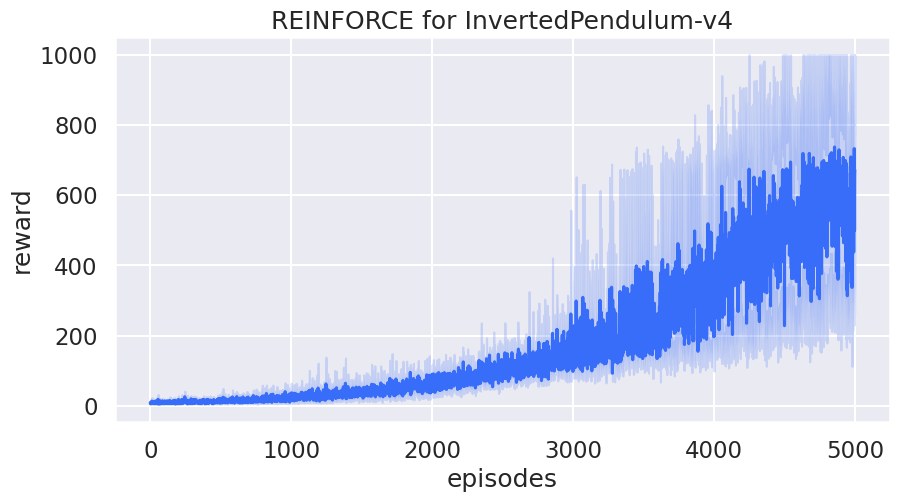

In [7]:
df1 = pd.DataFrame(rewards_over_seeds).melt()
df1.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df1).set(
    title="REINFORCE for InvertedPendulum-v4"
)
plt.show()

<img src="file://_static/img/tutorials/mujoco_reinforce_fig4.png">

Author: Siddarth Chandrasekar

License: MIT License

## References

[1] Williams, Ronald J.. “Simple statistical gradient-following
algorithms for connectionist reinforcement learning.” Machine Learning 8
(2004): 229-256.




# BaseLine Network

In [8]:
class BaselineNetwork(nn.Module):

    def __init__(self, obs_space_dims):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_space_dims, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class REINFORCEBaseline:
    """REINFORCEBaseline algorithm."""

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        """Initializes an agent that learns a policy via REINFORCEBaseline algorithm [1]
        to solve the task at hand (Inverted Pendulum v4).

        Args:
            obs_space_dims: Dimension of the observation space
            action_space_dims: Dimension of the action space
        """
        # Hyperparameters
        self.learning_rate = 1e-4  # Learning rate for policy optimization
        self.gamma = 0.99  # Discount factor
        self.eps = 1e-6  # small number for mathematical stability

        self.probs = []  # Stores probability values of the sampled action
        self.rewards = []  # Stores the corresponding rewards

        self.net = Policy_Network(obs_space_dims, action_space_dims)
        self.optimizer = torch.optim.AdamW(self.net.parameters(), lr=self.learning_rate)

        self.baseline = BaselineNetwork(obs_space_dims)

        self.baseline_optimizer = torch.optim.Adam(
            self.baseline.parameters(),
            lr=self.learning_rate
        )

        self.states = []

    def sample_action(self, state):

        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        action_means, action_stddevs = self.net(state)

        distrib = Normal(
            action_means[0] + self.eps,
            action_stddevs[0] + self.eps
        )

        action = distrib.sample()

        log_prob = distrib.log_prob(action).sum()

        self.probs.append(log_prob)
        self.states.append(state[0])

        return action.detach().numpy()

    def update(self):
        """Updates the policy network's weights."""
        running_g = 0
        returns = []

        for r in self.rewards[::-1]:
            running_g = r + self.gamma * running_g
            returns.insert(0, running_g)

        returns = torch.tensor(returns, dtype=torch.float32)

        states = torch.stack(self.states)

        baseline_values = self.baseline(states).squeeze()

        advantages = returns - baseline_values.detach()

        log_probs = torch.stack(self.probs).squeeze()

        policy_loss = -(log_probs * advantages).sum()

        value_loss = nn.MSELoss()(baseline_values, returns)

        self.optimizer.zero_grad()
        self.baseline_optimizer.zero_grad()

        policy_loss.backward()
        value_loss.backward()

        self.optimizer.step()
        self.baseline_optimizer.step()

        self.probs.clear()
        self.rewards.clear()
        self.states.clear()

In [10]:
# Create and wrap the environment
env = gym.make("InvertedPendulum-v4")
wrapped_env = gym.wrappers.RecordEpisodeStatistics(env, 50)  # Records episode-reward

total_num_episodes = int(5e3)  # Total number of episodes
# Observation-space of InvertedPendulum-v4 (4)
obs_space_dims = env.observation_space.shape[0]
# Action-space of InvertedPendulum-v4 (1)
action_space_dims = env.action_space.shape[0]
rewards_over_seeds = []

for seed in [1, 2, 3, 5, 8]:  # Fibonacci seeds
    # set seed
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # Reinitialize agent every seed
    agent = REINFORCEBaseline(obs_space_dims, action_space_dims)
    reward_over_episodes = []

    for episode in range(total_num_episodes):
        # gymnasium v26 requires users to set seed while resetting the environment
        obs, info = wrapped_env.reset(seed=seed)

        done = False
        while not done:
            action = agent.sample_action(obs)

            # Step return type - `tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]`
            # These represent the next observation, the reward from the step,
            # if the episode is terminated, if the episode is truncated and
            # additional info from the step
            obs, reward, terminated, truncated, info = wrapped_env.step(action)
            agent.rewards.append(reward)

            # End the episode when either truncated or terminated is true
            #  - truncated: The episode duration reaches max number of timesteps
            #  - terminated: Any of the state space values is no longer finite.
            #
            done = terminated or truncated

        reward_over_episodes.append(wrapped_env.return_queue[-1])
        agent.update()

        if episode % 1000 == 0:
            avg_reward = int(np.mean(wrapped_env.return_queue))
            print("Episode:", episode, "Average Reward:", avg_reward)

    rewards_over_seeds.append(reward_over_episodes)

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode: 0 Average Reward: 5
Episode: 1000 Average Reward: 40
Episode: 2000 Average Reward: 107
Episode: 3000 Average Reward: 174
Episode: 4000 Average Reward: 216
Episode: 0 Average Reward: 643
Episode: 1000 Average Reward: 21
Episode: 2000 Average Reward: 102
Episode: 3000 Average Reward: 213
Episode: 4000 Average Reward: 349
Episode: 0 Average Reward: 597
Episode: 1000 Average Reward: 18
Episode: 2000 Average Reward: 92
Episode: 3000 Average Reward: 578
Episode: 4000 Average Reward: 796
Episode: 0 Average Reward: 962
Episode: 1000 Average Reward: 18
Episode: 2000 Average Reward: 62
Episode: 3000 Average Reward: 222
Episode: 4000 Average Reward: 781
Episode: 0 Average Reward: 974
Episode: 1000 Average Reward: 24
Episode: 2000 Average Reward: 111
Episode: 3000 Average Reward: 232
Episode: 4000 Average Reward: 905


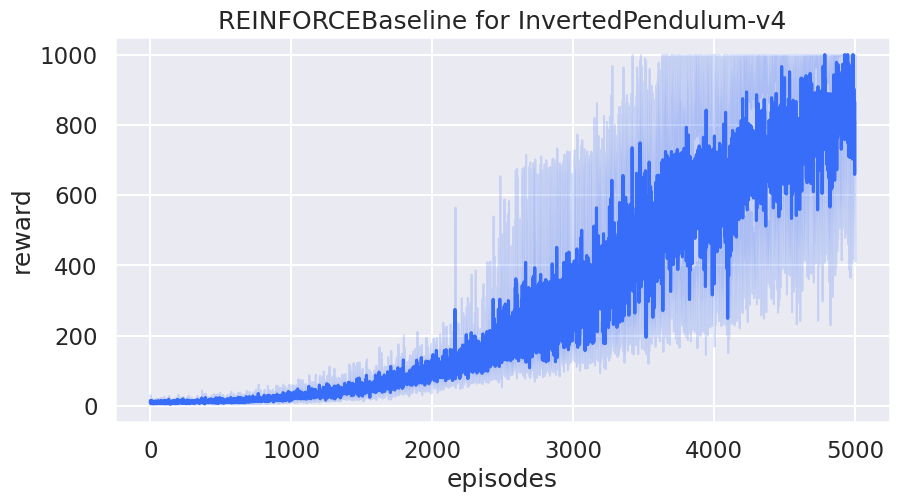

In [11]:
df2 = pd.DataFrame(rewards_over_seeds).melt()
df2.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df2).set(
    title="REINFORCEBaseline for InvertedPendulum-v4"
)
plt.show()

# A3C

In [21]:
class ActorCritic(nn.Module):

    def __init__(self, obs_dim, action_dim):

        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(obs_dim,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU()
        )

        self.actor_mean = nn.Linear(64,action_dim)
        self.actor_std = nn.Linear(64,action_dim)

        self.critic = nn.Linear(64,1)

    def forward(self,x):

        x=self.shared(x)

        mean=self.actor_mean(x)

        std=torch.log1p(torch.exp(self.actor_std(x)))

        value=self.critic(x)

        return mean,std,value

In [17]:
import os
import torch.multiprocessing as mp
from torch.distributions import Normal
import threading
import torch.optim as optim
import copy
import torch.nn.functional as F

In [22]:
class SharedAdam(torch.optim.Adam):
    """Adam optimizer whose running-average state (exp_avg, exp_avg_sq) lives
    in shared memory. This lets several worker processes all update ONE
    global model concurrently -- that concurrent, unsynchronized update is
    the "Asynchronous" in A3C. Without this, each process would end up with
    its own private optimizer state and the workers would not really be
    sharing a single set of weights.
    """

    def __init__(self, params, lr=1e-4, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        super().__init__(params, lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        for group in self.param_groups:
            for p in group["params"]:
                state = self.state[p]
                # Recent PyTorch versions require `step` to be a singleton TENSOR
                # (not a plain int) inside optimizer state -- and since this state
                # is shared across processes, that tensor has to live in shared
                # memory too, just like exp_avg/exp_avg_sq below.
                state["step"] = torch.zeros(1)
                state["exp_avg"] = torch.zeros_like(p.data)
                state["exp_avg_sq"] = torch.zeros_like(p.data)
                state["step"].share_memory_()
                state["exp_avg"].share_memory_()
                state["exp_avg_sq"].share_memory_()


In [23]:
def a3c_worker(rank, global_model, optimizer, seed, obs_space_dims, action_space_dims,
                total_episodes, results, counter, lock, n_steps=20, gamma=0.99, eps=1e-6):
    """One asynchronous actor-learner (one of the parallel "A"ctors in A3C).

    Each worker owns its own environment and its own LOCAL copy of the
    network. It periodically:
      1. syncs its local weights from the shared global model,
      2. rolls out up to `n_steps` transitions (or until the episode ends),
      3. bootstraps the return with the critic's value estimate V(s_{t+n})
         if the episode didn't terminate (this n-step + bootstrap is the
         actor-critic part -- unlike REINFORCE/REINFORCE+baseline, A3C does
         NOT wait for the full Monte-Carlo return),
      4. computes gradients locally and applies them DIRECTLY to the shared
         global model, with no locking around the gradient step -- workers
         can and do clobber each other's updates slightly (Hogwild-style
         async SGD). This lack of coordination is intentional and is what
         makes A3C "asynchronous" rather than just "parallel".
    """

    torch.manual_seed(seed * 1000 + rank)
    np.random.seed(seed * 1000 + rank)
    random.seed(seed * 1000 + rank)

    env = gym.make("InvertedPendulum-v4")
    local_model = ActorCritic(obs_space_dims, action_space_dims)

    while True:
        with lock:
            if counter.value >= total_episodes:
                break
            ep_idx = counter.value
            counter.value += 1

        local_model.load_state_dict(global_model.state_dict())
        obs, _ = env.reset(seed=seed)
        done = False
        ep_reward = 0.0

        while not done:
            log_probs, values, rewards = [], [], []

            for _ in range(n_steps):
                state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                mean, std, value = local_model(state_t)
                dist = Normal(mean + eps, std + eps)
                action = dist.sample()
                log_prob = dist.log_prob(action).sum()

                next_obs, reward, terminated, truncated, _ = env.step(
                    action.squeeze(0).detach().numpy()
                )
                done = terminated or truncated

                log_probs.append(log_prob)
                values.append(value.squeeze())
                rewards.append(reward)
                ep_reward += reward
                obs = next_obs

                if done:
                    break

            # Bootstrap from the critic if the rollout was cut short mid-episode
            if done:
                R = torch.tensor(0.0)
            else:
                with torch.no_grad():
                    _, _, v_next = local_model(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
                R = v_next.squeeze()

            returns = []
            for r in reversed(rewards):
                R = r + gamma * R
                returns.insert(0, R)
            returns = torch.stack(returns)

            values_t = torch.stack(values)
            advantages = returns - values_t

            actor_loss = -(torch.stack(log_probs) * advantages.detach()).sum()
            critic_loss = advantages.pow(2).sum()
            loss = actor_loss + 0.5 * critic_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(local_model.parameters(), 40.0)

            # Push local grads onto the SHARED global model and step the shared optimizer
            for local_param, global_param in zip(local_model.parameters(), global_model.parameters()):
                global_param._grad = local_param.grad
            optimizer.step()

            # Pull the (possibly updated-by-someone-else) global weights back down
            local_model.load_state_dict(global_model.state_dict())

        with lock:
            results[ep_idx] = ep_reward


def train_a3c(seed, obs_space_dims, action_space_dims, total_episodes,
              num_workers=4, n_steps=20, gamma=0.99):
    """Runs true asynchronous A3C for one seed: `num_workers` processes all
    read from and write to ONE shared global ActorCritic model at once."""

    global_model = ActorCritic(obs_space_dims, action_space_dims)
    global_model.share_memory()
    optimizer = SharedAdam(global_model.parameters(), lr=1e-4)

    manager = mp.Manager()
    results = manager.list([0.0] * total_episodes)
    counter = manager.Value("i", 0)
    lock = manager.Lock()

    workers = [
        mp.Process(
            target=a3c_worker,
            args=(rank, global_model, optimizer, seed, obs_space_dims, action_space_dims,
                  total_episodes, results, counter, lock, n_steps, gamma),
        )
        for rank in range(num_workers)
    ]

    for w in workers:
        w.start()
    for w in workers:
        w.join()

    return list(results)


In [24]:
# mp.set_start_method must be called once, before any process pool/model sharing happens
try:
    mp.set_start_method("fork", force=True)  # 'fork' is the safe default on Linux / Colab
except RuntimeError:
    pass

env = gym.make("InvertedPendulum-v4")
obs_space_dims = env.observation_space.shape[0]
action_space_dims = env.action_space.shape[0]
total_num_episodes = int(5e3)  # Total number of episodes

a3c_rewards_over_seeds = []

for seed in [1, 2, 3, 5, 8]:  # Fibonacci seeds
    a3c_reward_over_episodes = train_a3c(
        seed, obs_space_dims, action_space_dims, total_num_episodes,
        num_workers=4, n_steps=20, gamma=0.99,
    )
    a3c_rewards_over_seeds.append(a3c_reward_over_episodes)

    avg_reward = np.mean(a3c_reward_over_episodes[-100:])
    print("Seed:", seed, "Final 100-episode Average Reward:", avg_reward)


Seed: 1 Final 100-episode Average Reward: 54.94
Seed: 2 Final 100-episode Average Reward: 70.21
Seed: 3 Final 100-episode Average Reward: 46.35
Seed: 5 Final 100-episode Average Reward: 91.96
Seed: 8 Final 100-episode Average Reward: 39.52


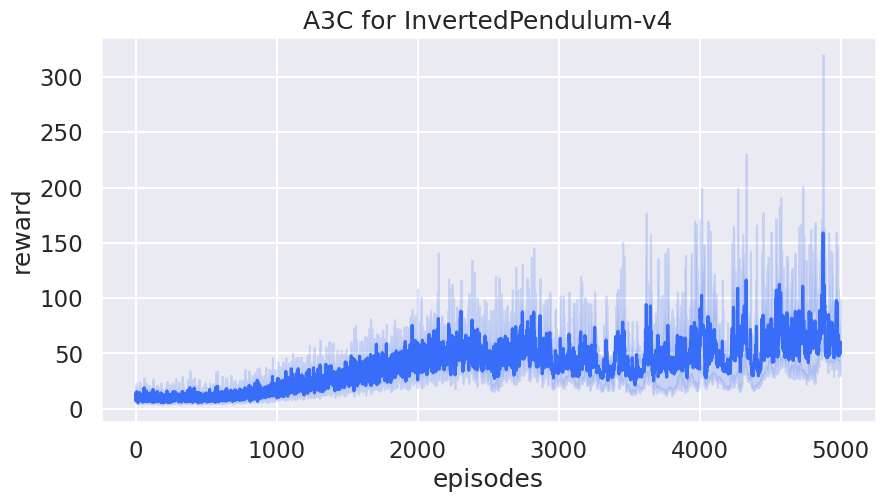

In [25]:
df3 = pd.DataFrame(a3c_rewards_over_seeds).melt()
df3.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df3).set(
    title="A3C for InvertedPendulum-v4"
)
plt.show()


# Experiment Loop

In [26]:
def train(agent_class, seeds, episodes):

    rewards_all=[]

    for seed in seeds:

        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        env=gym.make("InvertedPendulum-v4")

        agent=agent_class(
            env.observation_space.shape[0],
            env.action_space.shape[0]
        )

        rewards=[]

        for ep in range(episodes):

            state,_=env.reset(seed=seed)

            total_reward=0

            done=False

            while not done:

                action=agent.sample_action(state)

                next_state,reward,terminated,truncated,_=env.step(action)

                done=terminated or truncated

                agent.rewards.append(reward)

                state=next_state

                total_reward+=reward

            agent.update()

            rewards.append(total_reward)

        rewards_all.append(rewards)

    return np.array(rewards_all)

# Run Experiments - optional [no need to run]

In [ ]:
seeds = [1, 2, 3, 5, 8]
episodes = 5000

reinforce_rewards = train(REINFORCE, seeds, episodes)

baseline_rewards = train(REINFORCEBaseline, seeds, episodes)

# A3C needs its own runner (train() assumes a single sequential agent;
# A3C instead spins up several parallel worker processes sharing one model)
env = gym.make("InvertedPendulum-v4")
obs_space_dims = env.observation_space.shape[0]
action_space_dims = env.action_space.shape[0]

a3c_rewards = np.array([
    train_a3c(seed, obs_space_dims, action_space_dims, episodes, num_workers=4, n_steps=20)
    for seed in seeds
])


# Plot Comparison

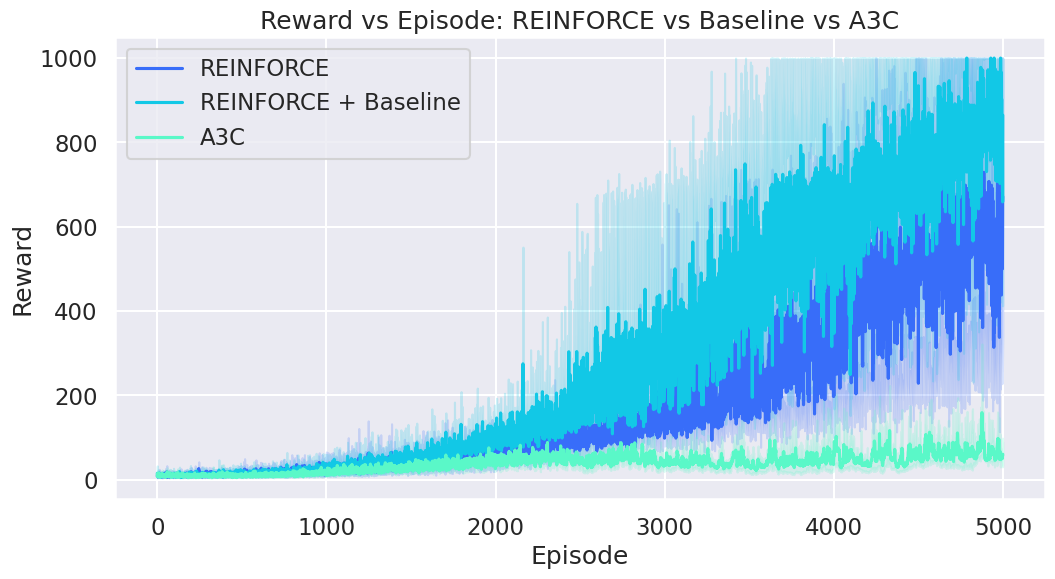

In [29]:
# Reuses df1 (REINFORCE), df2 (REINFORCE + Baseline), df3 (A3C) built earlier --
# no need to rerun training via the train()/train_a3c pipeline above.
df1["algorithm"] = "REINFORCE"
df2["algorithm"] = "REINFORCE + Baseline"
df3["algorithm"] = "A3C"

combined_df = pd.concat([df1, df2, df3], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", hue="algorithm", data=combined_df)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward vs Episode: REINFORCE vs Baseline vs A3C")
plt.legend()
plt.grid(True)
plt.show()
